# HW01

## 2. 线性代数与 NDArray

### 2.1.1 理论：向量点积

已知 $a = [2, -1, 3]^\top, b = [1, 4, -2]^\top$，求 $a \cdot b$。

$$a \cdot b = 2\cdot 1 + (-1)\cdot 4 + 3\cdot (-2) = 2 - 4 - 6 = -8$$

### 2.1.2 理论：矩阵乘法

$A$ 形状 $(2,3)$，$B$ 形状 $(3,2)$，故 $A\times B$ 形状为 **$(2,2)$**。

$$A\times B = \begin{bmatrix} 2 & -3 \\ 4 & 9 \end{bmatrix}$$

### 2.1.3 理论：Frobenius 范数（向量即欧氏范数）

对向量 $a$，$\|a\|_F = \|a\|_2 = \sqrt{2^2+(-1)^2+3^2} = \sqrt{14}$。

### 2.2 编程：NDArray（NumPy）

In [4]:
import numpy as np

# 1) X ~ N(0,1), shape (3,4)
X = np.random.randn(3, 4)

# 2) Y 全 1, shape (4,2)
Y = np.ones((4, 2))

# 3) Z = X @ Y
Z = X @ Y

# 4) Z[0,1] 与第 2 行（索引 1）全部元素
z_01 = Z[0, 1]
z_row2 = Z[1, :]

# 5) Frobenius 范数
Z_fro = np.linalg.norm(Z, ord="fro")

print("X.shape =", X.shape)
print("Y.shape =", Y.shape)
print("Z.shape =", Z.shape)
print("Z[0,1] =", z_01)
print("Z[1,:] =", z_row2)
print("||Z||_F =", Z_fro)

X.shape = (3, 4)
Y.shape = (4, 2)
Z.shape = (3, 2)
Z[0,1] = -2.3802758110620728
Z[1,:] = [2.33164884 2.33164884]
||Z||_F = 5.441601499987475


## 3. 概率与统计

### 3.1 理论：贝叶斯推断

$P(D)=0.001,\ P(Pos|D)=0.99,\ P(Pos|D^c)=0.02$。

$$P(D|Pos)=\frac{P(Pos|D)P(D)}{P(Pos|D)P(D)+P(Pos|D^c)P(D^c)}
=\frac{0.99\times 0.001}{0.99\times 0.001+0.02\times 0.999}
\approx 0.0472\ (\text{约 }4.72\%)$$

### 3.2 编程：中心极限定理模拟

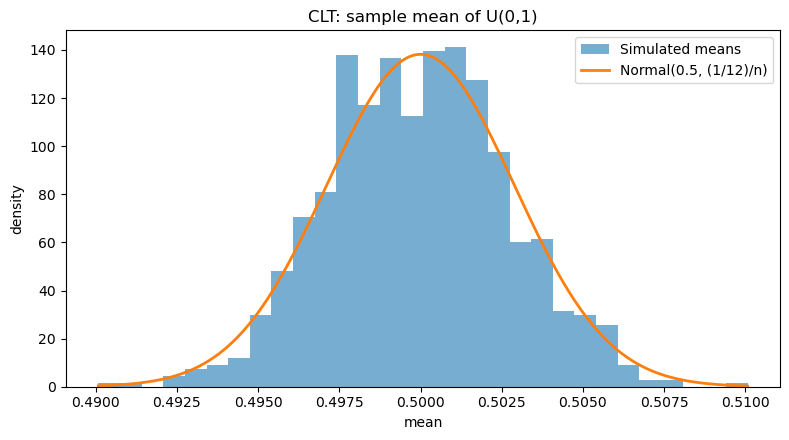

Empirical var = 7.686310191958932e-06
Theoretical var = 8.333333333333332e-06
Ratio emp/theory = 0.922357223035072


In [5]:
import numpy as np
import matplotlib.pyplot as plt

n = 10000
m = 1000

rng = np.random.default_rng(0)
means = np.mean(rng.random((m, n)), axis=1)

theory_var = (1 / 12) / n
emp_var = np.var(means, ddof=0)

mu = 0.5
sigma = np.sqrt(theory_var)

plt.figure(figsize=(8, 4.5))
count, bins, _ = plt.hist(means, bins=30, density=True, alpha=0.6, label="Simulated means")

xs = np.linspace(bins.min(), bins.max(), 400)
pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((xs - mu) / sigma) ** 2)
plt.plot(xs, pdf, linewidth=2, label="Normal(0.5, (1/12)/n)")

plt.title("CLT: sample mean of U(0,1)")
plt.xlabel("mean")
plt.ylabel("density")
plt.legend()
plt.tight_layout()
plt.show()

print("Empirical var =", emp_var)
print("Theoretical var =", theory_var)
print("Ratio emp/theory =", emp_var / theory_var)

## 4. 导数与反向传播

### 4.1 理论：梯度

$z=(w_1x_1+w_2x_2-y)^2$，$x_1=2,x_2=1,y=3$。令 $t=w_1x_1+w_2x_2-y$，则 $z=t^2$。

$$\frac{\partial z}{\partial w_1}=2t\cdot x_1,\quad \frac{\partial z}{\partial w_2}=2t\cdot x_2$$

当 $w_1=0.5,w_2=1$ 时 $t=-1$，故 $\partial z/\partial w_1=-4$，$\partial z/\partial w_2=-2$。

### 4.2 编程：手动反向传播与 torch.autograd 对比

In [6]:
import torch


def forward(x, w1, w2):
    a = x * w1
    b = a + w2
    L = b**2
    return a, b, L


def backward_manual(x, w1, w2):
    """x, w1, w2 为标量 Tensor；返回 Python float。"""
    a = x * w1
    b = a + w2
    L = b**2

    dL_db = 2 * b
    dL_da = dL_db * 1
    dL_dw2 = dL_db * 1
    dL_dw1 = dL_da * x

    return L.item(), dL_dw1.item(), dL_dw2.item()


x = torch.tensor(2.0)
w1 = torch.tensor(1.5)
w2 = torch.tensor(0.5)

# 须传入标量张量：若先 .item() 得到 float，则 L/dL 为 float，无法再 .item()
L_val, g_w1, g_w2 = backward_manual(x, w1, w2)
print("Manual: L =", L_val, "dL/dw1 =", g_w1, "dL/dw2 =", g_w2)

w1a = torch.tensor(1.5, requires_grad=True)
w2a = torch.tensor(0.5, requires_grad=True)
xa = torch.tensor(2.0)

_, _, La = forward(xa, w1a, w2a)
La.backward()

print("Autograd: L =", La.item(), "dL/dw1 =", w1a.grad.item(), "dL/dw2 =", w2a.grad.item())

Manual: L = 12.25 dL/dw1 = 14.0 dL/dw2 = 7.0
Autograd: L = 12.25 dL/dw1 = 14.0 dL/dw2 = 7.0


## 5. 线性方法与 Softmax 回归

### 5.1 理论：线性回归梯度

$L=\frac{1}{n}\sum_i (y_i-(wx_i+b))^2$，记 $e_i=y_i-(wx_i+b)$。

$$\frac{\partial L}{\partial w}=-\frac{2}{n}\sum_i x_i\,e_i=\frac{2}{n}\sum_i x_i\big((wx_i+b)-y_i\big)$$

$$\frac{\partial L}{\partial b}=-\frac{2}{n}\sum_i e_i=\frac{2}{n}\sum_i\big((wx_i+b)-y_i\big)$$

### 5.2 编程：从零实现 Softmax 回归（Mini-batch SGD）

In [7]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split


def one_hot(y, num_classes):
    out = np.zeros((y.shape[0], num_classes), dtype=np.float64)
    out[np.arange(y.shape[0]), y] = 1.0
    return out


def softmax(logits):
    z = logits - np.max(logits, axis=1, keepdims=True)
    expz = np.exp(z)
    return expz / np.sum(expz, axis=1, keepdims=True)


def cross_entropy(probs, y_onehot, eps=1e-12):
    p = np.clip(probs, eps, 1.0)
    return -np.mean(np.sum(y_onehot * np.log(p), axis=1))


def accuracy(probs, y):
    pred = np.argmax(probs, axis=1)
    return np.mean(pred == y)


digits = load_digits()
X = digits.data.astype(np.float64)
y = digits.target.astype(np.int64)
num_classes = 10

X = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-8)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
Y_train = one_hot(y_train, num_classes)
Y_test = one_hot(y_test, num_classes)

rng = np.random.default_rng(0)
W = 0.01 * rng.standard_normal((X_train.shape[1], num_classes))
b = np.zeros((1, num_classes))

batch_size = 32
lr = 0.1
epochs = 50
N = X_train.shape[0]

for epoch in range(1, epochs + 1):
    idx = rng.permutation(N)
    Xs, Ys = X_train[idx], Y_train[idx]

    for start in range(0, N, batch_size):
        xb = Xs[start : start + batch_size]
        yb = Ys[start : start + batch_size]

        logits = xb @ W + b
        probs = softmax(logits)

        B = xb.shape[0]
        dlogits = (probs - yb) / B
        dW = xb.T @ dlogits
        db = np.sum(dlogits, axis=0, keepdims=True)

        W -= lr * dW
        b -= lr * db

    train_probs = softmax(X_train @ W + b)
    test_probs = softmax(X_test @ W + b)
    tr_loss = cross_entropy(train_probs, Y_train)
    te_loss = cross_entropy(test_probs, Y_test)
    tr_acc = accuracy(train_probs, y_train)
    te_acc = accuracy(test_probs, y_test)

    if epoch % 10 == 0 or epoch == 1:
        print(
            f"epoch {epoch:02d} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
            f"test loss {te_loss:.4f} acc {te_acc:.4f}"
        )

epoch 01 | train loss 0.4635 acc 0.9269 | test loss 0.4822 acc 0.9194
epoch 10 | train loss 0.1264 acc 0.9791 | test loss 0.1657 acc 0.9500
epoch 20 | train loss 0.0856 acc 0.9889 | test loss 0.1366 acc 0.9583
epoch 30 | train loss 0.0673 acc 0.9910 | test loss 0.1249 acc 0.9639
epoch 40 | train loss 0.0564 acc 0.9944 | test loss 0.1189 acc 0.9639
epoch 50 | train loss 0.0489 acc 0.9958 | test loss 0.1142 acc 0.9694


## 6. 最大似然估计与逻辑回归

### 6.1 理论：正态 i.i.d. 的 MLE

似然 $L(\mu,\sigma^2)=\prod_i \frac{1}{\sqrt{2\pi\sigma^2}}\exp\big(-\frac{(x_i-\mu)^2}{2\sigma^2}\big)$。

对数似然求导可得 $\hat\mu=\frac{1}{n}\sum_i x_i$，$\hat\sigma^2=\frac{1}{n}\sum_i (x_i-\hat\mu)^2$。

### 6.2 编程：逻辑回归（造数 + BCE + 手写梯度下降 + 决策边界）

step 0001 | loss 0.6931 | train acc 1.0000
step 0200 | loss 0.0620 | train acc 1.0000
step 0400 | loss 0.0397 | train acc 1.0000
step 0600 | loss 0.0311 | train acc 1.0000
step 0800 | loss 0.0264 | train acc 1.0000
step 1000 | loss 0.0233 | train acc 1.0000
test acc = 1.0


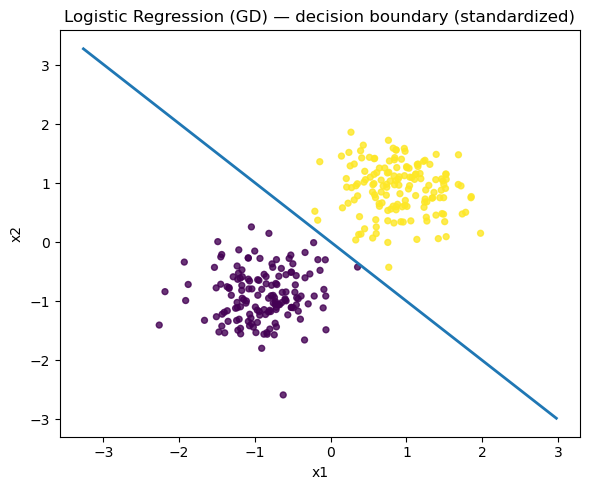

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def bce_loss(p, y, eps=1e-12):
    p = np.clip(p, eps, 1 - eps)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))


def predict_proba(X, w, b):
    return sigmoid(X @ w + b)


def predict(X, w, b, thr=0.5):
    return (predict_proba(X, w, b) >= thr).astype(np.int64)


rng = np.random.default_rng(0)
N = 400
N0 = N // 2
N1 = N - N0

X0 = rng.normal(loc=(-2.0, -2.0), scale=1.0, size=(N0, 2))
X1 = rng.normal(loc=(2.0, 2.0), scale=1.0, size=(N1, 2))
X = np.vstack([X0, X1])
y = np.hstack([np.zeros(N0, dtype=np.int64), np.ones(N1, dtype=np.int64)])

perm = rng.permutation(N)
X, y = X[perm], y[perm]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

mu = X_train.mean(axis=0, keepdims=True)
sd = X_train.std(axis=0, keepdims=True) + 1e-8
X_train_s = (X_train - mu) / sd
X_test_s = (X_test - mu) / sd

w = np.zeros(2, dtype=np.float64)
b = 0.0
lr = 0.1
steps = 1000

for t in range(1, steps + 1):
    p = predict_proba(X_train_s, w, b)
    loss = bce_loss(p, y_train)

    Ntr = X_train_s.shape[0]
    dlogits = (p - y_train) / Ntr
    dw = X_train_s.T @ dlogits
    db = np.sum(dlogits)

    w -= lr * dw
    b -= lr * db

    if t % 200 == 0 or t == 1:
        acc = np.mean(predict(X_train_s, w, b) == y_train)
        print(f"step {t:04d} | loss {loss:.4f} | train acc {acc:.4f}")

test_acc = np.mean(predict(X_test_s, w, b) == y_test)
print("test acc =", test_acc)

plt.figure(figsize=(6, 5))
plt.scatter(X_train_s[:, 0], X_train_s[:, 1], c=y_train, s=18, alpha=0.8)
plt.title("Logistic Regression (GD) — decision boundary (standardized)")
plt.xlabel("x1")
plt.ylabel("x2")

xs = np.linspace(X_train_s[:, 0].min() - 1, X_train_s[:, 0].max() + 1, 200)
if abs(w[1]) > 1e-12:
    ys = -(w[0] * xs + b) / w[1]
    plt.plot(xs, ys, linewidth=2)
plt.tight_layout()
plt.show()